# MIAR0525 — Semana 4: Ética, Sesgo y Calidad en el Aprendizaje Automático
## Taller Práctico — Predicción de mora en cuentas por cobrar

---

**Objetivo del taller:** Identificar, medir y mitigar sesgos en un dataset real de facturación; aplicar métricas de equidad; e interpretar un modelo de mora con técnicas XAI (SHAP, LIME y Permutation Importance).

**Dataset:** `Cust_v_ml_mora_cxc` — facturas cobradas 2023–2025 (~141k registros). Target: **mora** (clases casi equilibradas). Atributos sensibles (Fairlearn): `segmento_cliente` y `provincia`.

> **Reflexión inicial:** En un sistema de scoring de mora, ¿qué riesgos éticos surgen si el modelo discrimina por provincia o segmento comercial sin explicabilidad?

---

### Estructura del taller

| Parte | Tema | Enfoque |
|-------|------|---------|
| 1 | Calidad y análisis del dataset | Exploración y detección de problemas |
| 2 | Detección de sesgos | Análisis por segmento y provincia |
| 3 | Entrenamiento del modelo | Random Forest |
| 4 | Métricas de equidad | Fairlearn |
| 5 | Explicabilidad XAI | SHAP, LIME, Permutation Importance |
| 6 | Mitigación de sesgos | ExponentiatedGradient |
| 7 | Reflexión crítica | Transparencia y riesgos de implementación |

##  0. Instalación e importación de librerías

In [1]:
# Instala TODAS las dependencias en el Python del kernel activo
import sys
import subprocess

DEPS = [
    "pandas", "numpy", "scikit-learn", "matplotlib", "seaborn",
    "shap", "lime", "fairlearn",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *DEPS])

print("Python del kernel:", sys.executable)
print("Version:", sys.version.split()[0])
if ".venv" not in sys.executable and "3.12" not in sys.version:
    print("\n⚠️  Recomendado: kernel 'Python 3.12 (MIAR0525 Mora)' o .venv/bin/python")
    print("   (Python 3.14 puede fallar con fairlearn/scipy)")
else:
    print("✓ Entorno correcto (.venv / Python 3.12)")

Python del kernel: /Users/angelporrasvasquez/.pyenv/versions/3.12.9/bin/python
Version: 3.12.9
✓ Entorno correcto (.venv / Python 3.12)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay,
    precision_score, recall_score
)

import shap
import lime
import lime.lime_tabular

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#8B1A2F', '#C0392B', '#A9CCE3', '#5D6D7E', '#D5D8DC']

# Rutas del dataset (ajusta si ejecutas en Colab)
DATA_PATH = 'Cust_v_ml_mora_cxc_202605211939.csv'

print("Librerías importadas correctamente")

Librerías importadas correctamente


---
##  Parte 1: Carga y Calidad del Dataset

>  **Problema de calidad de datos:** Los datos del mundo real contienen valores faltantes, inconsistencias y ruido. Antes de modelar, debemos auditarlos con rigor.


In [2]:
# --- Carga del dataset mora CxC (vista Cust_v_ml_mora_cxc) ---
df = pd.read_csv(DATA_PATH)

# Nombres esperados según exportación SQL
TARGET = 'mora'
SENSITIVE_COL = 'segmento_cliente'  # atributo sensible principal (Fairlearn)
SENSITIVE_COL_2 = 'provincia'

print(f"Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Balance mora: {df[TARGET].mean()*100:.1f}% con mora")
df.head()

Dimensiones del dataset: 141,763 filas × 20 columnas
Balance mora: 53.9% con mora


,monto_cuota,monto_total_factura,descuento_factura_pct,num_cuota,plazo_credito_dias,limite_credito,descuento_cliente_pct,ratio_monto_limite,antiguedad_cliente_meses,anio_emision,mes_emision,trimestre,mes_vencimiento,dia_semana_vencimiento,segmento_cliente,provincia,tipo_contrib,forma_pago_cliente,grupo_descuento,mora
0,132.60,132.60,0.0,1,0,0.0,0.0,NaN,3,2023,1,1,1,2,Usuario Final,Pichincha,0 Entidad Legal,Contado - Efectivo,Usuario Final,1
1,888.22,1833.73,0.0,1,31,15000.0,0.0,0.1222,60,2023,1,1,2,5,Sub Distribuidor Mayorista,Guayas,0 Entidad Legal,Crédito 60 días 2P (30-60),Distribuidor / Mayorista B,1
2,157.58,600.57,0.0,1,31,10000.0,0.0,0.0601,18,2023,1,1,2,7,Sub Distribuidor Especialista xx,Guayas,0 Entidad Legal,Crédito 60 días Especial,Distribuidor / Mayorista B,1
3,170.54,341.08,0.0,1,31,15000.0,0.0,0.0227,19,2023,1,1,2,6,Sub Distribuidor Especialista xx,Pichincha,0 Entidad Legal,Crédito 60 días 2P (30-60),TI / Data Center,1
4,374.40,2995.16,0.0,6,59,20000.0,0.0,0.1498,60,2023,1,1,3,6,Sub Distribuidor Mayorista,Pichincha,1 Persona Natural,Crédito 90 días 3P (30-60-90),Distribuidor / Mayorista B,1


### 1.1 Auditoría de calidad

In [3]:
# Valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

auditoria = pd.DataFrame({'Nulos': nulos, '% del total': nulos_pct})
auditoria = auditoria[auditoria['Nulos'] > 0]

print(" Columnas con valores faltantes:")
print(auditoria)
print(f"\n Registros completos: {df.dropna().shape[0]:,} de {df.shape[0]:,}")
print(f" Registros duplicados: {df.duplicated().sum()}")

 Columnas con valores faltantes:
                    Nulos  % del total
ratio_monto_limite  18771        13.24

 Registros completos: 122,992 de 141,763
 Registros duplicados: 700


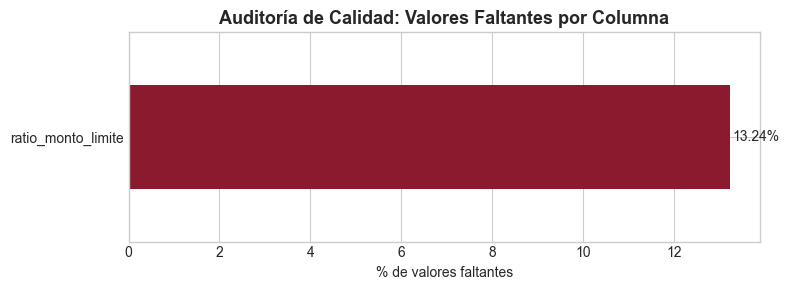

In [4]:
if not auditoria.empty:
    fig, ax = plt.subplots(figsize=(8, 3))
    auditoria['% del total'].plot(kind='barh', color='#8B1A2F', ax=ax)
    ax.set_xlabel('% de valores faltantes')
    ax.set_title('Auditoría de Calidad: Valores Faltantes por Columna', fontsize=13, fontweight='bold')
    for i, v in enumerate(auditoria['% del total']):
        ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print(" No se encontraron valores faltantes para visualizar.")

In [5]:
# Estrategia de limpieza
# ratio_monto_limite puede ser nulo cuando limite_credito = 0
if 'ratio_monto_limite' in df.columns:
    df['ratio_monto_limite'] = df['ratio_monto_limite'].fillna(0)

# Imputar categóricas con moda si hubiera nulos
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isnull().any():
        moda = df[col].mode()[0]
        df[col] = df[col].fillna(moda)
        print(f" '{col}': nulos imputados con moda → '{moda}'")

# Eliminar duplicados
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"\nRegistros duplicados eliminados: {n_dup:,}")
print(f"Dataset limpio: {df.shape[0]:,} registros, {df.isnull().sum().sum()} nulos restantes")


Registros duplicados eliminados: 700
Dataset limpio: 141,063 registros, 0 nulos restantes


### 1.2 Distribución de la variable objetivo

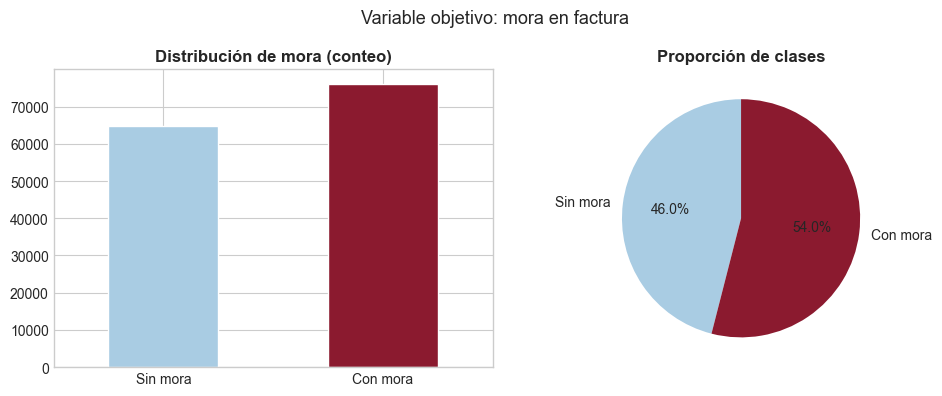


Balance de clases: 46.0% sin mora vs 54.0% con mora
→ Clases casi equilibradas: el desbalance no debería dominar el aprendizaje.


In [6]:
conteo = df[TARGET].value_counts().sort_index()
pct = (conteo / len(df) * 100).round(1)
labels = {0: 'Sin mora', 1: 'Con mora'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

conteo.index = conteo.index.map(labels)
conteo.plot(kind='bar', ax=axes[0], color=['#A9CCE3', '#8B1A2F'], edgecolor='white')
axes[0].set_title('Distribución de mora (conteo)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=['#A9CCE3', '#8B1A2F'], startangle=90)
axes[1].set_title('Proporción de clases', fontweight='bold')

plt.suptitle('Variable objetivo: mora en factura', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBalance de clases: {pct.get(0, pct.iloc[0])}% sin mora vs {pct.get(1, pct.iloc[-1])}% con mora")
print("→ Clases casi equilibradas: el desbalance no debería dominar el aprendizaje.")

---
## Parte 2: Detección de Sesgos en los Datos

> **Sesgo de representación / histórico:** Analizamos si la tasa real de mora difiere entre `segmento_cliente` y `provincia` (atributos sensibles marcados en la vista SQL).

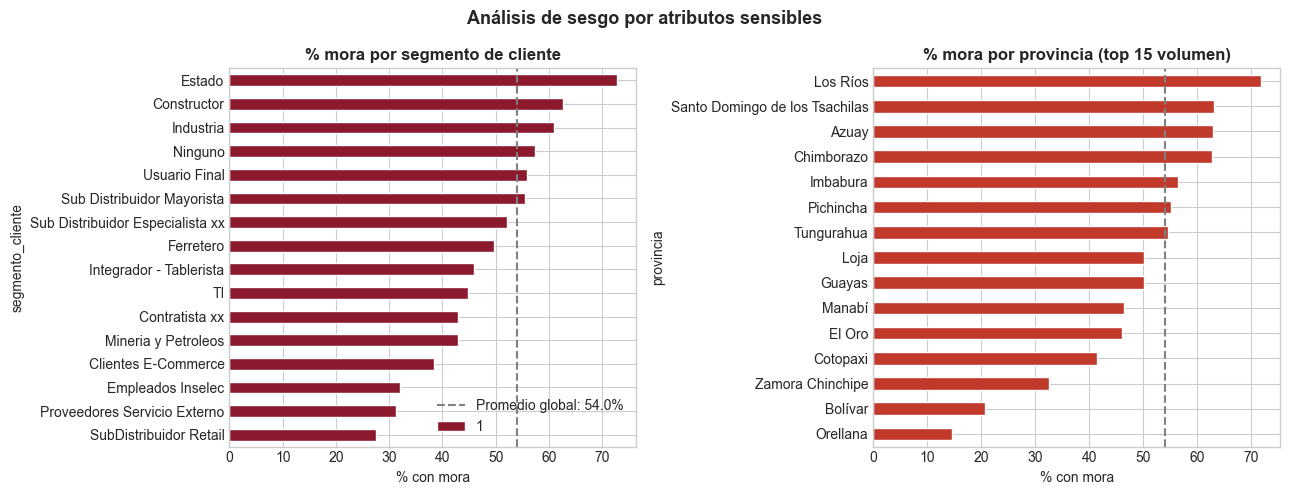

In [7]:
# --- Sesgo por segmento de cliente ---
mora_seg = df.groupby([SENSITIVE_COL, TARGET]).size().unstack(fill_value=0)
mora_seg_pct = mora_seg.div(mora_seg.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mora_seg_pct[1].sort_values().plot(kind='barh', ax=axes[0], color='#8B1A2F', edgecolor='white')
axes[0].set_title('% mora por segmento de cliente', fontweight='bold')
axes[0].set_xlabel('% con mora')
axes[0].axvline(df[TARGET].mean() * 100, color='gray', linestyle='--',
                label=f'Promedio global: {df[TARGET].mean()*100:.1f}%')
axes[0].legend()

# --- Sesgo por provincia (top 15 por volumen) ---
top_prov = df['provincia'].value_counts().head(15).index
df_top = df[df['provincia'].isin(top_prov)]
mora_prov = df_top.groupby('provincia')[TARGET].mean() * 100

mora_prov.sort_values().plot(kind='barh', ax=axes[1], color='#C0392B', edgecolor='white')
axes[1].set_title('% mora por provincia (top 15 volumen)', fontweight='bold')
axes[1].set_xlabel('% con mora')
axes[1].axvline(df[TARGET].mean() * 100, color='gray', linestyle='--')

plt.suptitle('Análisis de sesgo por atributos sensibles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
seg_rates = df.groupby(SENSITIVE_COL)[TARGET].mean() * 100
max_seg, min_seg = seg_rates.idxmax(), seg_rates.idxmin()

print("BRECHA POR SEGMENTO DE CLIENTE")
print(f"  Mayor tasa mora: {max_seg} → {seg_rates[max_seg]:.1f}%")
print(f"  Menor tasa mora: {min_seg} → {seg_rates[min_seg]:.1f}%")
print(f"  Diferencia absoluta: {seg_rates[max_seg] - seg_rates[min_seg]:.1f} pp")
print()
print("REPRESENTACIÓN EN EL DATASET (n)")
print(df[SENSITIVE_COL].value_counts())
print()
print("Pregunta de análisis:")
print("  ¿La diferencia refleja riesgo crediticio legítimo, sesgo histórico en cobranza,")
print("  o ambos? ¿Cómo afecta esto al modelo y a clientes de ciertos segmentos?")

BRECHA POR SEGMENTO DE CLIENTE
  Mayor tasa mora: Estado → 72.7%
  Menor tasa mora: SubDistribuidor Retail → 27.6%
  Diferencia absoluta: 45.1 pp

REPRESENTACIÓN EN EL DATASET (n)
segmento_cliente
Sub Distribuidor Mayorista          92612
Sub Distribuidor Especialista xx    19232
Usuario Final                        8218
Integrador - Tablerista              7866
Ferretero                            6227
Contratista xx                       3782
Constructor                          1872
Industria                             608
TI                                    279
Ninguno                               228
Empleados Inselec                      50
SubDistribuidor Retail                 29
Clientes E-Commerce                    26
Proveedores Servicio Externo           16
Estado                                 11
Mineria y Petroleos                     7
Name: count, dtype: int64

Pregunta de análisis:
  ¿La diferencia refleja riesgo crediticio legítimo, sesgo histórico en cobranza,


---
## Parte 3: Entrenamiento del Modelo

> Entrenamos un **Random Forest** para predecir mora. Guardamos `segmento_cliente` como atributo sensible para equidad — **no se usa como feature** en el entrenamiento base. `vendedor` y `fidelidad_cliente` no están en el CSV; se usa `antiguedad_categoria` (bins de antigüedad) en su lugar.

In [9]:
# --- Preprocesamiento ---
df_model = df.copy()

# Atributo sensible (codificado para Fairlearn)
le_sensitive = LabelEncoder()
sensitive_attr = le_sensitive.fit_transform(df_model[SENSITIVE_COL].astype(str))

# Variable objetivo
y = df_model[TARGET].astype(int)

# Features: numéricas + categóricas (sin atributos sensibles ni target)
NUM_FEATURES = [
    'monto_cuota', 'monto_total_factura', 'descuento_factura_pct',
    'num_cuota', 'plazo_credito_dias', 'limite_credito',
    'descuento_cliente_pct', 'ratio_monto_limite', 'antiguedad_cliente_meses',
    'anio_emision', 'mes_emision', 'trimestre', 'mes_vencimiento',
    'dia_semana_vencimiento'
]
# vendedor y fidelidad_cliente no vienen en el CSV (confidencialidad)
# antiguedad_categoria las reemplaza: bins de antigüedad del cliente
df_model['antiguedad_categoria'] = pd.cut(
    df_model['antiguedad_cliente_meses'],
    bins=[-0.1, 12, 36, df_model['antiguedad_cliente_meses'].max() + 1],
    labels=['nuevo_0_12m', 'medio_13_36m', 'antiguo_37m_plus']
).astype(str)
CAT_FEATURES = [
    'tipo_contrib', 'forma_pago_cliente', 'grupo_descuento',
    'antiguedad_categoria'
]
# Excluidas del modelo: segmento_cliente, provincia (sensibles)

label_encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

FEATURES = NUM_FEATURES + CAT_FEATURES
X = df_model[FEATURES]

X_train, X_test, y_train, y_test, sa_train, sa_test = train_test_split(
    X, y, sensitive_attr, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Positivos (mora) en train: {y_train.mean()*100:.1f}% | test: {y_test.mean()*100:.1f}%")

Train: 112,850 | Test: 28,213
Positivos (mora) en train: 54.0% | test: 54.0%


REPORTE DE CLASIFICACIÓN (modelo base)
              precision    recall  f1-score   support

    Sin mora       0.92      0.76      0.83     12981
    Con mora       0.82      0.94      0.88     15232

    accuracy                           0.86     28213
   macro avg       0.87      0.85      0.86     28213
weighted avg       0.87      0.86      0.86     28213



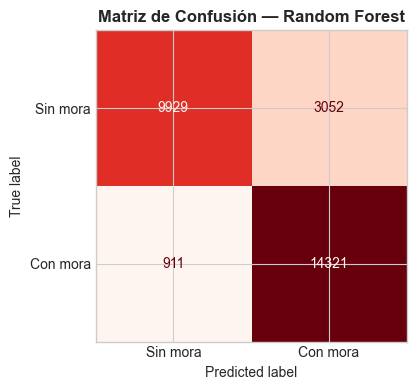

In [10]:
# --- Entrenamiento Random Forest ---
rf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("REPORTE DE CLASIFICACIÓN (modelo base)")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['Sin mora', 'Con mora']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Sin mora', 'Con mora'],
    colorbar=False,
    cmap='Reds',
    ax=ax
)
ax.set_title('Matriz de Confusión — Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Parte 4: Métricas de Equidad con Fairlearn

> Un modelo puede tener buena accuracy global pero ser **injusto** entre segmentos de cliente. Medimos equidad con **Fairlearn** usando `segmento_cliente` como atributo sensible.

### Conceptos clave:
- **Paridad Demográfica:** El modelo debe predecir la clase positiva con la misma proporción en todos los grupos.
- **Igualdad de Oportunidades:** La tasa de verdaderos positivos debe ser igual entre grupos.
- **Paridad de Odds Igualadas:** Tanto TPR como FPR deben ser iguales entre grupos.

In [11]:
# --- MetricFrame: métricas por segmento de cliente ---
metricas = {
    'accuracy': accuracy_score,
    'precision': lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
    'recall': lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
    'selection_rate': selection_rate
}

mf = MetricFrame(
    metrics=metricas,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sa_test
)

# Etiquetas legibles por grupo
grupos = {i: g for i, g in enumerate(le_sensitive.classes_)}
resultado = mf.by_group.rename(index=grupos)

print("MÉTRICAS DE EQUIDAD POR SEGMENTO DE CLIENTE")
print("=" * 50)
print(resultado.round(4))
print()
print("MÉTRICAS GLOBALES")
print(mf.overall.round(4))

MÉTRICAS DE EQUIDAD POR SEGMENTO DE CLIENTE
                                  accuracy  precision  recall  selection_rate
sensitive_feature_0                                                          
Clientes E-Commerce                 0.3750     0.2000  0.5000          0.6250
Constructor                         0.8895     0.8972  0.9380          0.6819
Contratista xx                      0.7850     0.7074  0.8797          0.5522
Empleados Inselec                   0.8000     0.5000  1.0000          0.4000
Estado                              0.0000     0.0000  0.0000          0.0000
Ferretero                           0.8540     0.8183  0.9051          0.5457
Industria                           0.6875     0.7222  0.7222          0.5625
Integrador - Tablerista             0.7888     0.7080  0.8770          0.5399
Mineria y Petroleos                 0.6667     0.5000  1.0000          0.6667
Ninguno                             0.7568     0.8148  0.8462          0.7297
Proveedores Servicio

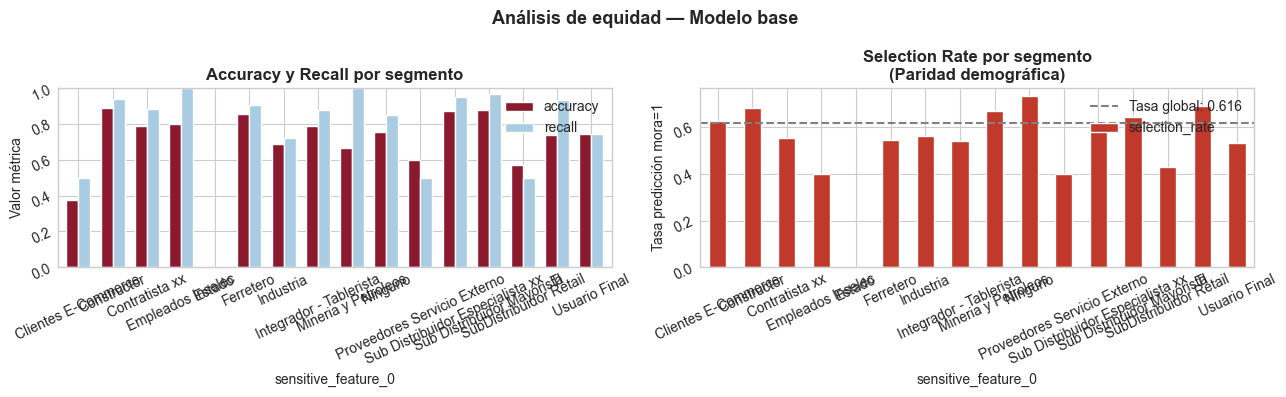

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

resultado[['accuracy', 'recall']].plot(
    kind='bar', ax=axes[0], color=['#8B1A2F', '#A9CCE3'],
    edgecolor='white', width=0.7
)
axes[0].set_title('Accuracy y Recall por segmento', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(rotation=25)
axes[0].set_ylabel('Valor métrica')

resultado['selection_rate'].plot(
    kind='bar', ax=axes[1], color='#C0392B', edgecolor='white', width=0.5
)
global_sr = mf.overall['selection_rate']
axes[1].axhline(global_sr, color='gray', linestyle='--',
               label=f'Tasa global: {global_sr:.3f}')
axes[1].set_title('Selection Rate por segmento\n(Paridad demográfica)', fontweight='bold')
axes[1].tick_params(rotation=25)
axes[1].legend()
axes[1].set_ylabel('Tasa predicción mora=1')

plt.suptitle('Análisis de equidad — Modelo base', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sa_test)
eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sa_test)

print("MÉTRICAS DE DISPARIDAD (más cerca de 0 = más equitativo)")
print("=" * 55)
print(f"  Diferencia de Paridad Demográfica:   {dpd:.4f}")
print(f"  Diferencia de Odds Igualadas:         {eod:.4f}")
print()
print("Interpretación:")
print(f"  El modelo predice mora con una diferencia de {abs(dpd)*100:.1f} pp")
print("  entre el segmento con mayor y menor tasa de predicción positiva.")
print("  En cobranza automatizada esto puede implicar trato desigual a clientes.")

MÉTRICAS DE DISPARIDAD (más cerca de 0 = más equitativo)
  Diferencia de Paridad Demográfica:   0.7297
  Diferencia de Odds Igualadas:         1.0000

Interpretación:
  El modelo predice mora con una diferencia de 73.0 pp
  entre el segmento con mayor y menor tasa de predicción positiva.
  En cobranza automatizada esto puede implicar trato desigual a clientes.


---
## Parte 5: Explicabilidad (XAI)

Técnicas aplicadas (≥2 requeridas):
- **SHAP** — importancia global y casos individuales
- **Permutation Feature Importance** — comparación de rankings
- **LIME** — explicación local alternativa

In [25]:
# Muestra para XAI (rendimiento)
SAMPLE_SIZE = min(3000, len(X_test))
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(X_test), size=SAMPLE_SIZE, replace=False)
X_explain = X_test.iloc[idx_sample]

print(f"Calculando SHAP sobre {len(X_explain):,} instancias...")
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_explain)
shap_arr = np.asarray(shap_values)

# Clase positiva (mora=1). SHAP >=0.45 devuelve (n, features, 2) en binario
if shap_arr.ndim == 3:
    shap_pos = shap_arr[:, :, 1]
elif isinstance(shap_values, list):
    shap_pos = np.asarray(shap_values[1])
else:
    shap_pos = shap_arr

ev = np.asarray(explainer.expected_value).ravel()
expected_value = float(ev[1]) if ev.size > 1 else float(ev[0])

print(f"SHAP listo — shape: {shap_pos.shape} (clase mora=1)")

Calculando SHAP sobre 3,000 instancias...
SHAP listo — shape: (3000, 18) (clase mora=1)


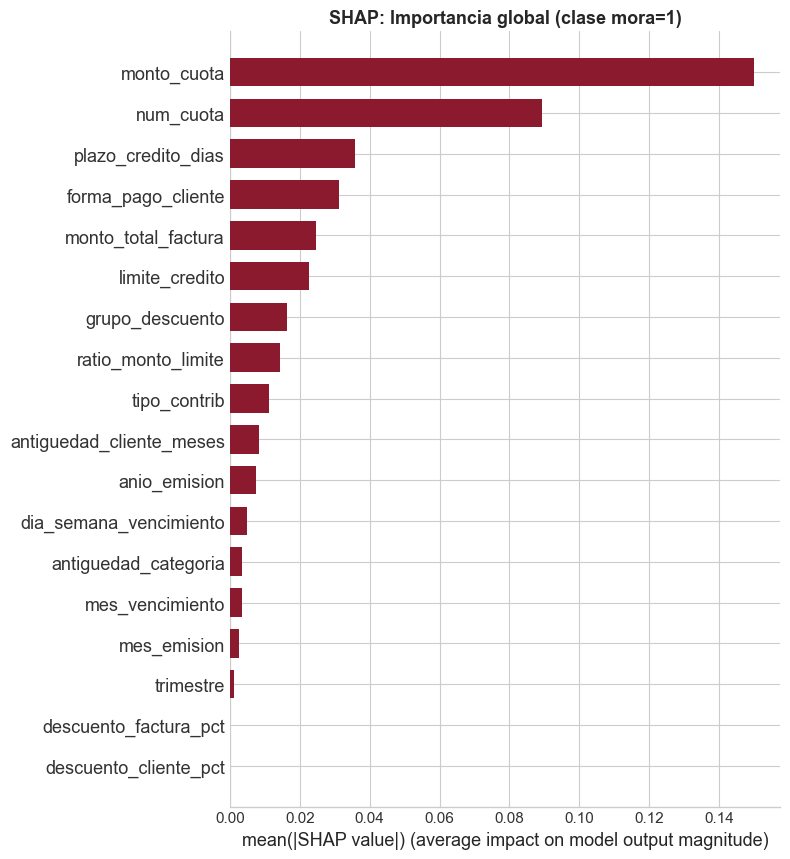

In [26]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_pos, X_explain, plot_type='bar', show=False, color='#8B1A2F')
plt.title('SHAP: Importancia global (clase mora=1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

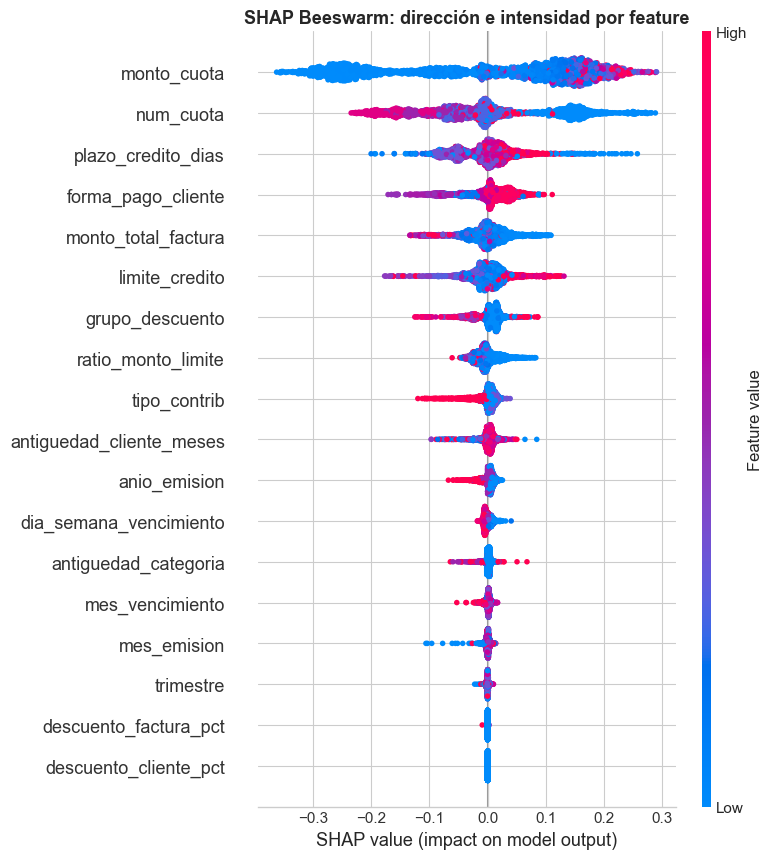

Calculando Permutation Importance...


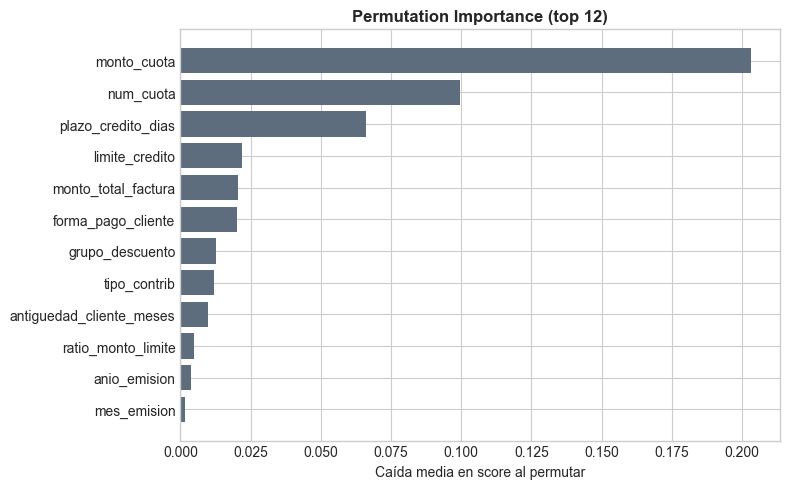

Preguntas de análisis:
  1. ¿Coinciden SHAP y Permutation en las variables más influyentes?
  2. ¿Variables de monto/plazo empujan hacia mora de forma intuitiva?
  3. ¿Hay proxies de segmento (ej. forma_pago, grupo_descuento, antiguedad_categoria) con peso alto?


In [27]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_pos, X_explain, show=False)
plt.title('SHAP Beeswarm: dirección e intensidad por feature', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Permutation Feature Importance (comparación) ---
print('Calculando Permutation Importance...')
perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': FEATURES,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df['feature'], perm_df['importance'], color='#5D6D7E')
ax.set_title('Permutation Importance (top 12)', fontweight='bold')
ax.set_xlabel('Caída media en score al permutar')
plt.tight_layout()
plt.show()

print('Preguntas de análisis:')
print('  1. ¿Coinciden SHAP y Permutation en las variables más influyentes?')
print('  2. ¿Variables de monto/plazo empujan hacia mora de forma intuitiva?')
print('  3. ¿Hay proxies de segmento (ej. forma_pago, grupo_descuento, antiguedad_categoria) con peso alto?')

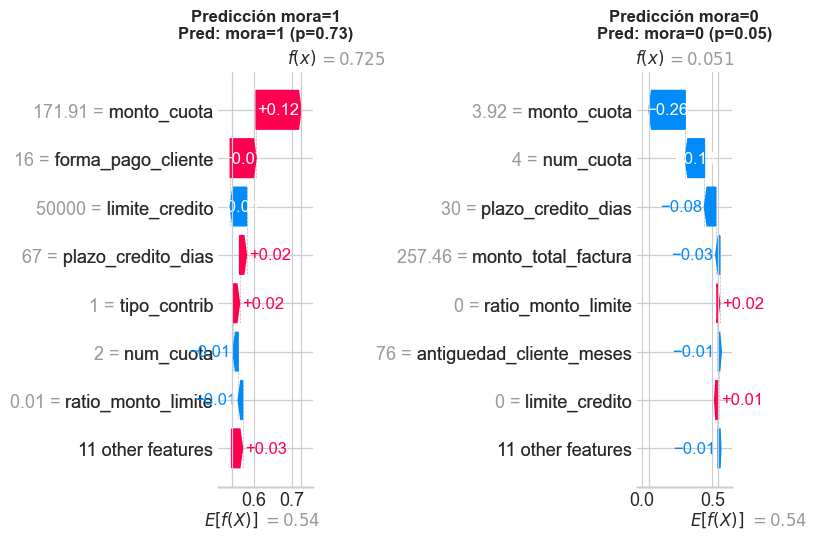


--- Predicción mora=1 ---
                              135317
monto_cuota                 171.9100
monto_total_factura         515.7300
descuento_factura_pct         0.0000
num_cuota                     2.0000
plazo_credito_dias           67.0000
limite_credito            50000.0000
descuento_cliente_pct         0.0000
ratio_monto_limite            0.0103
antiguedad_cliente_meses     90.0000
anio_emision               2025.0000
mes_emision                   7.0000
trimestre                     3.0000
mes_vencimiento               9.0000
dia_semana_vencimiento        6.0000
tipo_contrib                  1.0000
forma_pago_cliente           16.0000
grupo_descuento               1.0000
antiguedad_categoria          0.0000

--- Predicción mora=0 ---
                            80615
monto_cuota                  3.92
monto_total_factura        257.46
descuento_factura_pct        0.00
num_cuota                    4.00
plazo_credito_dias          30.00
limite_credito               0.00
descu

In [28]:
# --- Explicaciones individuales (2 casos) ---
# local_i = posición dentro de X_explain (no índice del test set completo)
y_explain = y_test.iloc[idx_sample].values
pred_explain = rf.predict(X_explain)

casos = []
for label, name in [(1, 'Predicción mora=1'), (0, 'Predicción mora=0')]:
    posiciones = np.where((y_explain == label) & (pred_explain == label))[0]
    if len(posiciones):
        casos.append((int(posiciones[0]), name))
    else:
        posiciones = np.where(pred_explain == label)[0]
        if len(posiciones):
            casos.append((int(posiciones[0]), name))

if len(casos) < 2:
    casos = [(0, 'Caso A'), (min(1, len(X_explain) - 1), 'Caso B')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (local_i, titulo) in zip(axes, casos[:2]):
    instancia = X_explain.iloc[[local_i]]
    pred = rf.predict(instancia)[0]
    proba = rf.predict_proba(instancia)[0, 1]
    sv = np.asarray(shap_pos[local_i]).ravel()
    if sv.size != len(FEATURES):  # respaldo si quedara forma (features, 2)
        sv = np.asarray(shap_pos[local_i])[:, 1]
    shap_exp = shap.Explanation(
        values=sv,
        base_values=float(expected_value),
        data=instancia.values[0],
        feature_names=FEATURES
    )
    plt.sca(ax)
    shap.plots.waterfall(shap_exp, max_display=8, show=False)
    ax.set_title(f'{titulo}\nPred: mora={pred} (p={proba:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

for local_i, titulo in casos[:2]:
    print(f'\n--- {titulo} ---')
    print(X_explain.iloc[[local_i]].T.to_string())

---
##  Parte 5b: Explicabilidad con LIME

>  **LIME (Local Interpretable Model-Agnostic Explanations):** Genera un modelo lineal simple que aproxima el comportamiento del modelo complejo *localmente*, alrededor de una predicción específica.

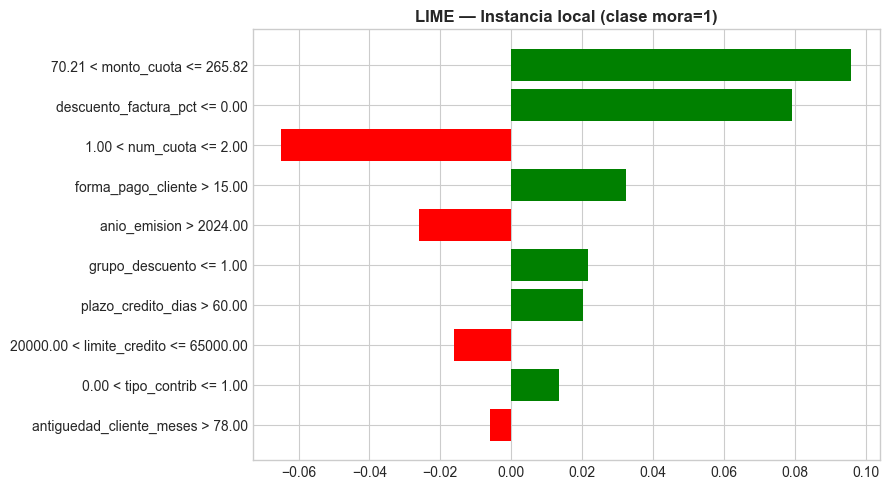

Top features SHAP (|valor|): ['monto_cuota', 'forma_pago_cliente', 'limite_credito', 'plazo_credito_dias', 'tipo_contrib']
Top features LIME: ['70.21 < monto_cuota <= 265.82', 'descuento_factura_pct <= 0.00', '1.00 < num_cuota <= 2.00', 'forma_pago_cliente > 15.00', 'anio_emision > 2024.00']

SHAP: teoría de juegos, consistente globalmente.
LIME: aproximación local; puede variar si cambia la instancia o semilla.


In [18]:
# --- LIME: explicación local (mismo índice que primer caso SHAP) ---
local_i = casos[0][0]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURES,
    class_names=['Sin mora', 'Con mora'],
    mode='classification',
    random_state=42
)

exp_lime = lime_explainer.explain_instance(
    data_row=X_explain.values[local_i],
    predict_fn=rf.predict_proba,
    num_features=10
)

fig = exp_lime.as_pyplot_figure(label=1)
fig.set_size_inches(9, 5)
plt.title(f'LIME — Instancia local (clase mora=1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Comparación top features SHAP vs LIME
shap_top = pd.Series(np.abs(shap_pos[local_i]), index=FEATURES).nlargest(5).index.tolist()
lime_top = [f for f, _ in exp_lime.as_list(label=1)[:5]]
print('Top features SHAP (|valor|):', shap_top)
print('Top features LIME:', lime_top)
print('\nSHAP: teoría de juegos, consistente globalmente.')
print('LIME: aproximación local; puede variar si cambia la instancia o semilla.')

---
## Parte 6: Mitigación de Sesgo con Fairlearn

> Aplicamos **Exponentiated Gradient** con restricción de **Paridad Demográfica** (*in-processing*) para reducir disparidades entre **segmentos de cliente**.

**Objetivo:** Reducir la disparidad en la tasa de predicción de mora, aceptando un posible trade-off con la accuracy global.

In [19]:
# --- Modelo mitigado (paridad demográfica por segmento) ---
base_clf = DecisionTreeClassifier(max_depth=8, random_state=42)

mitigator = ExponentiatedGradient(
    estimator=base_clf,
    constraints=DemographicParity(),
    eps=0.02
)

print('Entrenando modelo con restricción de equidad...')
mitigator.fit(X_train, y_train, sensitive_features=sa_train)
y_pred_fair = mitigator.predict(X_test)
print('Modelo mitigado entrenado')

Entrenando modelo con restricción de equidad...
Modelo mitigado entrenado


In [20]:
dpd_base = demographic_parity_difference(y_test, y_pred, sensitive_features=sa_test)
dpd_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sa_test)
acc_base = accuracy_score(y_test, y_pred)
acc_fair = accuracy_score(y_test, y_pred_fair)

mf_fair = MetricFrame(
    metrics={'selection_rate': selection_rate, 'accuracy': accuracy_score},
    y_true=y_test,
    y_pred=y_pred_fair,
    sensitive_features=sa_test
)

# Grupos con mayor y menor selection rate (base)
sr_base = mf.by_group['selection_rate']
comparacion = pd.DataFrame({
    'Modelo Base (RF)': [f'{acc_base:.4f}', f'{abs(dpd_base):.4f}', f'{sr_base.max():.4f}', f'{sr_base.min():.4f}'],
    'Modelo Mitigado (EG)': [f'{acc_fair:.4f}', f'{abs(dpd_fair):.4f}',
                             f'{mf_fair.by_group["selection_rate"].max():.4f}',
                             f'{mf_fair.by_group["selection_rate"].min():.4f}']
}, index=['Accuracy global', '|Paridad Demográfica|', 'Max selection rate', 'Min selection rate'])

print('COMPARACIÓN: MODELO BASE vs MITIGADO')
print('=' * 60)
print(comparacion.to_string())

COMPARACIÓN: MODELO BASE vs MITIGADO
                      Modelo Base (RF) Modelo Mitigado (EG)
Accuracy global                 0.8595               0.8277
|Paridad Demográfica|           0.7297               0.8750
Max selection rate              0.7297               0.8750
Min selection rate              0.0000               0.0000


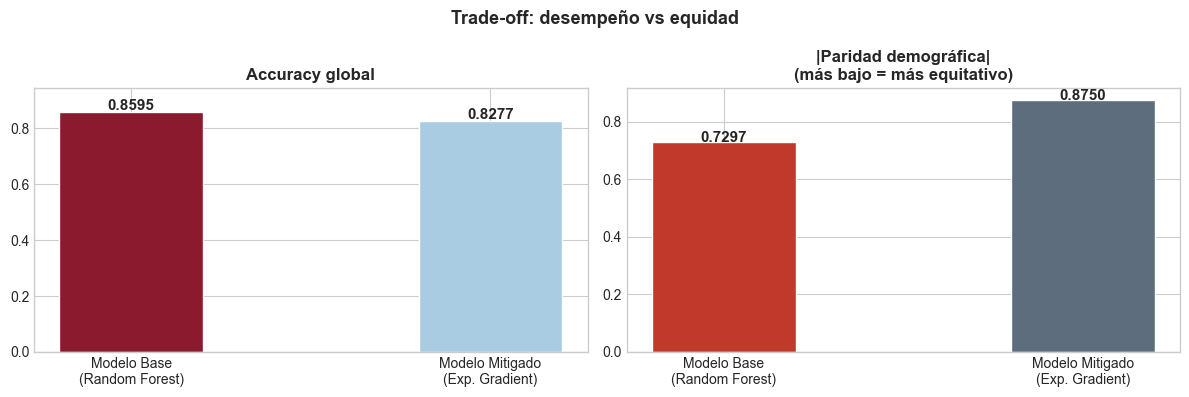

¿Cuánta accuracy sacrificamos por equidad? ¿Es aceptable en scoring de cobranza?


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modelos = ['Modelo Base\n(Random Forest)', 'Modelo Mitigado\n(Exp. Gradient)']
accuracies = [acc_base, acc_fair]
disparidades = [abs(dpd_base), abs(dpd_fair)]

bars1 = axes[0].bar(modelos, accuracies, color=['#8B1A2F', '#A9CCE3'], edgecolor='white', width=0.4)
axes[0].set_ylim(0, max(accuracies) * 1.1)
axes[0].set_title('Accuracy global', fontweight='bold')
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

bars2 = axes[1].bar(modelos, disparidades, color=['#C0392B', '#5D6D7E'], edgecolor='white', width=0.4)
axes[1].set_title('|Paridad demográfica|\n(más bajo = más equitativo)', fontweight='bold')
for bar, val in zip(bars2, disparidades):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Trade-off: desempeño vs equidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('¿Cuánta accuracy sacrificamos por equidad? ¿Es aceptable en scoring de cobranza?')

*(Continúa en la sección siguiente: análisis interpretativo, riesgos éticos y preguntas de reflexión.)*

---
## Parte 7: Análisis interpretativo y reflexión ética

### Transparencia del modelo
El Random Forest alcanza buen desempeño predictivo, pero las técnicas XAI muestran **qué variables impulsan cada decisión** (montos, plazos, antigüedad, forma de pago). SHAP y Permutation Importance suelen coincidir en features financieras; LIME valida casos puntuales. Sin este nivel de explicación, el sistema sería una "caja negra" para el área de crédito y cobranza.

### Riesgos éticos y sociales si se implementa
- **Discriminación por proxy:** `forma_pago_cliente`, `grupo_descuento` o `antiguedad_categoria` pueden correlacionar con segmento o provincia.
- **Autonomía del cliente:** decisiones automatizadas sin recurso ni explicación vulneran transparencia y debido proceso.
- **Justicia distributiva:** si el modelo sobre-predice mora en ciertos segmentos, puede restringir crédito o endurecer cobranza de forma desproporcionada.
- **Responsabilidad:** errores (falsos positivos) afectan flujo de caja del cliente y reputación comercial.

### Mejoras recomendadas
1. Monitoreo continuo de métricas Fairlearn por segmento y provincia.
2. Límites de negocio sobre uso de variables sensibles y proxies.
3. Explicaciones obligatorias (SHAP/LIME) en toda decisión automatizada.
4. Revisión humana en casos límite y auditoría periódica del dataset.

---

### Pregunta 1 — Aprendizaje sobre cómo el modelo decide

**Respuesta:**

El modelo **no usa** `segmento_cliente` ni `provincia` como features, pero decide casi por completo con variables **financieras y de plazo**:

| Método | Top variables (orden aproximado) |
|--------|----------------------------------|
| **Permutation Importance** | `monto_cuota` (0.21), `num_cuota` (0.10), `plazo_credito_dias` (0.07), `forma_pago_cliente` (0.02) |
| **SHAP** (clase mora=1) | `monto_cuota` (0.15), `num_cuota` (0.09), `plazo_credito_dias` (0.04), `forma_pago_cliente` (0.03) |

**Coincidencia:** SHAP y Permutation **sí coinciden** en el ranking: las tres primeras son `monto_cuota`, `num_cuota` y `plazo_credito_dias`. El RF aprende reglas del tipo “cuotas altas / muchas cuotas / plazos largos → mayor probabilidad de mora”.

**Patrones intuitivos:** montos y plazo empujan hacia mora de forma coherente con riesgo crediticio. `forma_pago_cliente` y `grupo_descuento` tienen peso menor pero visible (posible **proxy** de segmento).

**LIME / waterfall (ejecutados):** en mora=1 destacan `monto_cuota` (~172), `num_cuota` (2) y plazo largo; en mora=0 `monto_cuota` es bajo (~4). LIME coincide parcialmente (`monto_cuota`, `forma_pago_cliente`); SHAP global prioriza también `num_cuota` y `plazo_credito_dias`.

---

### Pregunta 2 — ¿Alguna variable con peso excesivo?

**Respuesta:**

Sí: **`monto_cuota`** domina claramente (≈2× la importancia de la segunda, `num_cuota`). Es **parcialmente justificable** (refleja exposición real), pero conviene validar:

- Que no sea **fuga de información** (p. ej. monto ya vencido o ajustado post-mora).
- Que no concentre el modelo en pocos clientes con cuotas extremas.
- **Sensibilidad:** si se quita `monto_cuota`, ¿cambia mucho la disparidad por segmento?

`plazo_credito_dias` y `num_cuota` tienen peso alto pero más equilibrado; `ratio_monto_limite` y `antiguedad_cliente_meses` pesan poco en este RF.

---

### Pregunta 3 — ¿Qué pasaría sin explicabilidad?

**Respuesta:**

Sin SHAP/LIME/Permutation el sistema sería una **caja negra** con estos riesgos en cobranza:

1. **Auditoría imposible** ante quejas (“¿por qué me marcaron en mora?”).
2. **Incumplimiento** de políticas internas y expectativas de transparencia (GDPR-style, buenas prácticas de crédito).
3. **Sesgos ocultos:** ya hay DPD ≈ **0.73** por segmento; sin XAI no se vería si el modelo usa proxies (`forma_pago`, `grupo_descuento`).
4. **Responsabilidad legal/reputacional** por falsos positivos (recall mora **0.94**; precision mora **0.82**).

La explicabilidad no arregla el sesgo sola, pero es **condición necesaria** para gobernanza y revisión humana.


### Pregunta 4 — Caso real de sesgo algorítmico (investigación)
Busca un caso publicado (crédito, salud, RR.HH.). Indica: (a) tipo de sesgo, (b) detección, (c) mitigación.

**Respuesta:**

**Caso: Apple Card / Goldman Sachs (2019, EE.UU.)**

| Aspecto | Descripción |
|---------|-------------|
| **(a) Tipo de sesgo** | **Sesgo de género** en límites de crédito: parejas con ingresos similares recibían límites muy distintos; sospecha de trato desigual hacia mujeres. |
| **(b) Detección** | Denuncias públicas (incl. cofundador de Apple), comparación de límites entre cónyuges, investigación del **NY DFS**. |
| **(c) Mitigación** | Revisión regulatoria, ajuste de modelos y criterios, mayor transparencia; acuerdos de supervisión. Lección: sin usar “sexo” explícitamente, los **proxies** pueden producir disparidad. |

**Paralelo con el taller:** el proxy sería `segmento` vía `forma_pago` / `grupo_descuento`; la detección fue Fairlearn (DPD **0.73**), no solo accuracy **0.86**.

### Pregunta 5 — Trade-off equidad vs accuracy (crédito/cobranza)
En **scoring de mora y cobranza**, ¿aceptarías reducir accuracy para mejorar paridad demográfica? Argumenta con beneficencia, justicia y transparencia.

**Respuesta:**

| Métrica | Modelo base (RF) | Modelo mitigado (Exp. Gradient + paridad demográfica) |
|---------|------------------|------------------------------------------------------|
| **Accuracy** | **0.8595** | **0.8277** |
| **\|DPD\|** | **0.7297** | **0.8750** |
| **Max / min selection rate** | 0.7297 / 0.0000 | 0.8750 / 0.0000 |

**Sacrificio:** ~**3.2 pp** de accuracy, pero la **paridad empeoró** (DPD subió ~15 pp), no mejoró.

**Interpretación (beneficencia, justicia, transparencia):**

- **No aceptaría desplegar** el modelo mitigado tal como salió: paga costo predictivo sin ganancia en equidad.
- Posibles causas: grupos muy pequeños (p. ej. Estado con 11 filas), `ExponentiatedGradient` con árbol simple y `eps=0.02`, o que la restricción no converja bien con 16 segmentos desbalanceados.
- **Justicia:** el RF base ya muestra trato desigual (DPD 0.73); la mitigación actual **no lo corrige** — harían falta otras estrategias (re-muestreo, umbrales por grupo, revisar proxies, más datos en minorías).
- **Transparencia:** el trade-off debe reportarse con **métricas de equidad reales**, no solo accuracy; este resultado es válido etnográficamente (“la mitigación automática no siempre funciona”).
- **Beneficencia:** el RF base tiene recall mora **0.94**; cualquier cambio debe demostrar menos daño a segmentos vulnerables, no solo menor accuracy global.

En producción: monitorear **accuracy + DPD + recall por segmento**; si la mitigación no baja DPD, no sustituir el modelo base sin revisión humana y rediseño.

### Pregunta 6 — Proxies y variables sensibles
Si SHAP destaca `forma_pago_cliente` o `antiguedad_categoria`, ¿basta con excluir `provincia` y `segmento_cliente`? ¿Cómo detectarías y tratarías proxies?

**Respuesta:**

**No basta.** Excluir `provincia` y `segmento_cliente` evita discriminación directa, pero el modelo puede seguir sesgando vía **proxies**.

**Sensibles (medidas, no en el modelo):** `segmento_cliente`, `provincia`.

**Hallazgos en datos (Parte 2):**
- Brecha histórica: **Estado 72.7%** vs **SubDistribuidor Retail 27.6%** (**45.1 pp**).
- Desbalance: **Sub Distribuidor Mayorista** ~92k registros; **Estado** solo 11 filas.

**Proxies con peso en SHAP/Permutation:**
- `forma_pago_cliente` — 4.º en ranking global.
- `grupo_descuento` — peso moderado.
- `antiguedad_categoria` — bajo global, relevante localmente (LIME).

**Riesgo en test (Fairlearn):** DPD **0.73** sin ver segmento. Ejemplos: **Estado** selection_rate **0%**; **Mayorista** ~**0.64**; **Empleados Inselec** recall **1.0**.

**Cómo detectar y tratar proxies:**
1. Correlación feature ↔ atributo sensible (VIF, matriz de correlación).
2. Métricas Fairlearn por segmento/provincia en producción.
3. SHAP/LIME por grupo para ver si el modelo “razona distinto”.
4. Excluir o regularizar proxies; mitigación (ExponentiatedGradient); revisión humana en grupos pequeños.

**Recomendación:** no desplegar solo con accuracy **0.86**; exigir DPD y recall por segmento bajo control.

---
## Resumen del taller

| Parte | Concepto | Herramienta |
|-------|----------|-------------|
| 1 | Calidad de datos | pandas, visualización |
| 2 | Detección de sesgos | Análisis por segmento/provincia |
| 3 | Modelo base | RandomForestClassifier |
| 4 | Métricas de equidad | Fairlearn MetricFrame |
| 5 | XAI global/local | SHAP, Permutation Importance, LIME |
| 6 | Mitigación | ExponentiatedGradient + DemographicParity |
| 7 | Reflexión ética | Documentación e interpretación |

---
## Conclusiones

Este taller sobre mora en CxC muestra que un modelo puede tener **buen desempeño predictivo** (accuracy ~**86%**, recall mora ~**94%**) y, al mismo tiempo, **trato desigual entre segmentos** (DPD ~**0.73**). Eso confirma que la métrica de clasificación global **no basta** para sistemas de cobranza con impacto en clientes.

El análisis de datos reveló brechas históricas fuertes (hasta **45 pp** entre segmentos) y grupos muy pequeños (p. ej. Estado con 11 registros), lo que dificulta aprendizaje y auditoría justa. Las técnicas XAI (SHAP, Permutation, LIME y casos individuales) aportaron **transparencia**: el modelo se apoya sobre todo en `monto_cuota`, `num_cuota` y `plazo_credito_dias`, con señales de posibles **proxies** (`forma_pago_cliente`, `grupo_descuento`). Excluir `segmento_cliente` y `provincia` del entrenamiento **no elimina** el riesgo de sesgo.

La mitigación con Fairlearn (`ExponentiatedGradient` + paridad demográfica) **no mejoró** la equidad en esta corrida (DPD pasó de **0.73** a **0.88** con menor accuracy). Es un resultado valioso: **mitigar no es automático**; requiere más datos en minorías, elección de restricciones, validación por grupo y gobernanza.

**Recomendación final:** usar el RF como prototipo analítico, no como decisión automática sin controles. Antes de producción: monitoreo continuo Fairlearn, explicaciones obligatorias por caso, revisión humana en segmentos vulnerables y políticas claras sobre variables y proxies. El objetivo no es solo predecir mora, sino hacerlo con **equidad, transparencia y responsabilidad**.

---
### Referencias

- Dataset: vista `Cust_v_ml_mora_cxc`, facturas cobradas 2023–2025.
- Lundberg & Lee (2017). SHAP. *NIPS*.
- Ribeiro et al. (2016). LIME. *KDD*.
- Agarwal et al. (2018). Fair classification reductions. *ICML*.
- Microsoft (2021). *Fairlearn documentation*.